In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv("data.csv")

In [3]:
print("first few rows of data:")
print(data.head())

first few rows of data:
  Make       Model  Year             Engine Fuel Type  Engine HP  \
0  BMW  1 Series M  2011  premium unleaded (required)      335.0   
1  BMW    1 Series  2011  premium unleaded (required)      300.0   
2  BMW    1 Series  2011  premium unleaded (required)      300.0   
3  BMW    1 Series  2011  premium unleaded (required)      230.0   
4  BMW    1 Series  2011  premium unleaded (required)      230.0   

   Engine Cylinders Transmission Type     Driven_Wheels  Number of Doors  \
0               6.0            MANUAL  rear wheel drive              2.0   
1               6.0            MANUAL  rear wheel drive              2.0   
2               6.0            MANUAL  rear wheel drive              2.0   
3               6.0            MANUAL  rear wheel drive              2.0   
4               6.0            MANUAL  rear wheel drive              2.0   

                         Market Category Vehicle Size Vehicle Style  \
0  Factory Tuner,Luxury,High-Performanc

In [4]:
print("\ninfo about dataset:")
print(data.info())


info about dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11914 entries, 0 to 11913
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Make               11914 non-null  object 
 1   Model              11914 non-null  object 
 2   Year               11914 non-null  int64  
 3   Engine Fuel Type   11911 non-null  object 
 4   Engine HP          11845 non-null  float64
 5   Engine Cylinders   11884 non-null  float64
 6   Transmission Type  11914 non-null  object 
 7   Driven_Wheels      11914 non-null  object 
 8   Number of Doors    11908 non-null  float64
 9   Market Category    8172 non-null   object 
 10  Vehicle Size       11914 non-null  object 
 11  Vehicle Style      11914 non-null  object 
 12  highway MPG        11914 non-null  int64  
 13  city mpg           11914 non-null  int64  
 14  Popularity         11914 non-null  int64  
 15  MSRP               11914 non-null  int64  
dtypes

In [5]:

data = data.drop_duplicates()

print("\nmissing values before cleaning:")
print(data.isnull().sum())


missing values before cleaning:
Make                    0
Model                   0
Year                    0
Engine Fuel Type        3
Engine HP              69
Engine Cylinders       30
Transmission Type       0
Driven_Wheels           0
Number of Doors         6
Market Category      3376
Vehicle Size            0
Vehicle Style           0
highway MPG             0
city mpg                0
Popularity              0
MSRP                    0
dtype: int64


In [6]:
for col in data.columns:
    if data[col].dtype != "object":
        data[col].fillna(data[col].median(), inplace=True)

C:\Users\chava\AppData\Local\Temp\ipykernel_9652\1179871329.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data[col].fillna(data[col].median(), inplace=True)
C:\Users\chava\AppData\Local\Temp\ipykernel_9652\1179871329.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For exa

In [7]:
print("\nmissing values after cleaning:")
print(data.isnull().sum())


missing values after cleaning:
Make                    0
Model                   0
Year                    0
Engine Fuel Type        3
Engine HP               0
Engine Cylinders        0
Transmission Type       0
Driven_Wheels           0
Number of Doors         0
Market Category      3376
Vehicle Size            0
Vehicle Style           0
highway MPG             0
city mpg                0
Popularity              0
MSRP                    0
dtype: int64


In [8]:
corr = data.corr(numeric_only=True)
print("\ncorrelation between features:")
print(corr)


correlation between features:
                      Year  Engine HP  Engine Cylinders  Number of Doors  \
Year              1.000000   0.335238         -0.034152         0.247739   
Engine HP         0.335238   1.000000          0.773664        -0.129217   
Engine Cylinders -0.034152   0.773664          1.000000        -0.149798   
Number of Doors   0.247739  -0.129217         -0.149798         1.000000   
highway MPG       0.244972  -0.362952         -0.596246         0.115081   
city mpg          0.188417  -0.355036         -0.562599         0.121013   
Popularity        0.085874   0.041947          0.038325        -0.057213   
MSRP              0.209635   0.658693          0.538531        -0.144353   

                  highway MPG  city mpg  Popularity      MSRP  
Year                 0.244972  0.188417    0.085874  0.209635  
Engine HP           -0.362952 -0.355036    0.041947  0.658693  
Engine Cylinders    -0.596246 -0.562599    0.038325  0.538531  
Number of Doors      0.11508

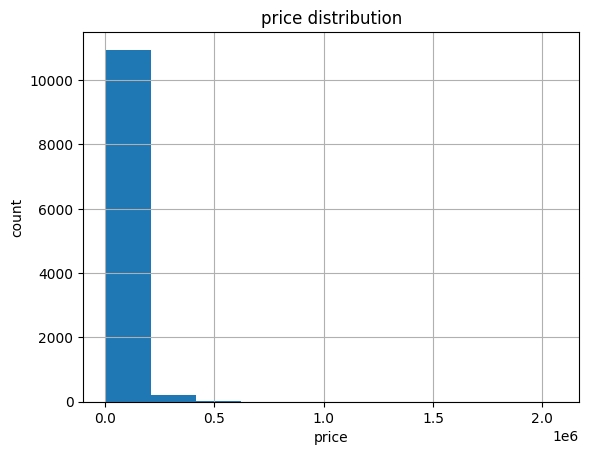

In [9]:
plt.figure()
data["MSRP"].hist()
plt.title("price distribution")
plt.xlabel("price")
plt.ylabel("count")
plt.show()

In [10]:
if "Horsepower" in data.columns:
    plt.figure()
    plt.scatter(data["Horsepower"], data["MSRP"])
    plt.title("horsepower vs price")
    plt.xlabel("horsepower")
    plt.ylabel("price")
    plt.show()

In [11]:
if "Engine Size" in data.columns:
    plt.figure()
    plt.scatter(data["Engine Size"], data["MSRP"])
    plt.title("engine size vs price")
    plt.xlabel("engine size")
    plt.ylabel("price")
    plt.show()

In [12]:
print("\nfinal shape of data:")
print(data.shape)

print("\nall done dataset is clean and ready for model")


final shape of data:
(11199, 16)

all done dataset is clean and ready for model


for col in data.columns:
    if data[col].dtype == "object":
        data[col].fillna(data[col].mode()[0], inplace=True)